# IMT 574 Final Project Report:<br>Airbnb Rating Prediction and Feature Importance in Seattle
### Team members: Jimin Keel, Vivien Wang, Anna Chi

## 1. Describe the dataset you chose. 

We use Seattle’s Airbnb dataset from Inside Airbnb. 
The dataset contains information about Airbnb listings in Seattle, including host data, geographic information, listing characteristics, and review scores. Some example features include price, property_type, room_type, accommodates, availability, and review_scores_rating. <br>
The data was collected from public Airbnb listings through web scraping and published on the Inside Airbnb website as periodic snapshots. <br>
We chose this dataset because it provides rich information about listings and hosts, which allows us to analyze factors that may influence Airbnb ratings and listing performance.

## 2. Define a research question. 

### Main Question: Which features are most important in predicting Airbnb listing rating scores?
To answer this question, we applied three supervised learning models, including `Random Forest`, `Gradient Boosting`, and `K-Nearest Neighbors (KNN)`, to predict Airbnb listing rating scores based on selected listing and host features. <br>
We then examined feature importance from the tree-based models to identify which factors contribute most to predicting rating scores.
### Sub Question: Does the importance of these features differ across cities compared to overall Seattle?
To explore this question, we used `Gradient Boosting` models to compare feature importance across different cities. <br>
We selected 6 main neighborhoods in Seattle and analyzed whether the importance of the selected features varies across these areas.


## 3. Why is this algorithm a good way of answering your research question? 

We chose `Gradient Boosting` as our main algorithm because it achieved the **highest accuracy** among the models we tested. <br>
`Gradient Boosting` is also useful for our research question because it provides feature importance scores, which help us identify which variables are most important in predicting Airbnb listing rating scores. <br>
In addition, `Gradient Boosting` can capture nonlinear relationships and interactions between features, which are common in real-world datasets like Airbnb listings. Therefore, it is a suitable model for both prediction and understanding feature importance.

## 4. Using the data you chose and the algorithm you chose, read in your data and run your model.

### 1. Data Processing

In [2]:
# Import Packages

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', None)

In [6]:
# Load the Dataset

raw = pd.read_csv("listings.csv.gz")

In [7]:
# Check the Dataset
raw.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6606,https://www.airbnb.com/rooms/6606,20250925032813,2025-09-25,city scrape,"Fab, private seattle urban cottage!","This tiny cottage is only 15x10, but it has ev...","A peaceful yet highly accessible neighborhood,...",https://a0.muscache.com/pictures/45742/21116d7...,14942,https://www.airbnb.com/users/show/14942,Joyce,2009-04-26,"Seattle, WA",I am a therapist/innkeeper.I know my city well...,within a few hours,100%,82%,t,https://a0.muscache.com/im/users/14942/profile...,https://a0.muscache.com/im/users/14942/profile...,Wallingford,5.0,5.0,"['email', 'phone']",t,t,Neighborhood highlights,Wallingford,Other neighborhoods,47.65444,-122.33629,Entire guesthouse,Entire home/apt,1,1.0,1 bath,1.0,1.0,"[""Free parking on premises"", ""Dedicated worksp...",$99.00,30,1125,30.0,30.0,1125.0,1125.0,30.0,1125.0,NaN,t,27,57,87,177,2025-09-25,161,0,0,95,1,0,0.0,2009-07-17,2024-09-07,4.60,4.67,4.67,4.83,4.77,4.88,4.57,str-opli-19-002622,f,3,3,0,0,0.82
1,9419,https://www.airbnb.com/rooms/9419,20250925032813,2025-09-25,city scrape,Glorious sun room w/ memory foambed,This beautiful double room features sun filled...,"Lots of restaurants (see our guide book) bars,...",https://a0.muscache.com/pictures/56645186/e5fb...,30559,https://www.airbnb.com/users/show/30559,Angielena,2009-08-09,"Seattle, WA",I am a visual artist who is the director ...,within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/User-...,https://a0.muscache.com/im/pictures/user/User-...,Georgetown,10.0,11.0,"['email', 'phone']",t,t,Neighborhood highlights,Georgetown,Other neighborhoods,47.55017,-122.31937,Private room in rental unit,Private room,2,3.0,3 shared baths,1.0,2.0,"[""Baking sheet"", ""Luggage dropoff allowed"", ""C...",$71.00,2,90,2.0,2.0,90.0,90.0,2.0,90.0,NaN,t,0,22,52,327,2025-09-25,220,14,1,60,14,84,5964.0,2010-07-30,2025-08-31,4.73,4.80,4.75,4.92,4.89,4.70,4.69,Exempt,f,10,0,10,0,1.19
2,9596,https://www.airbnb.com/rooms/9596,20250925032813,2025-09-25,previous scrape,"the down home , spacious, central and fab!","We are in a great neighborhood, quiet, full of...","if you arrive early for check in at 3, I reco...",https://a0.muscache.com/pictures/665252/102d18...,14942,https://www.airbnb.com/users/show/14942,Joyce,2009-04-26,"Seattle, WA",I am a therapist/innkeeper.I know my city well...,within a few hours,100%,82%,t,https://a0.muscache.com/im/users/14942/profile...,https://a0.muscache.com/im/users/14942/profile...,Wallingford,5.0,5.0,"['email', 'phone']",t,t,Neighborhood highlights,Wallingford,Other neighborhoods,47.65608,-122.33602,Entire rental unit,Entire home/apt,4,

##### Interesting Columns (Target Variable / Feature Candidates)
  
- **Target variable**: `review_scores_rating` (we will convert the 1–5 scale into two classes, to address lower variance issue in 1-5 scale rating.)
- **Index**: `neighbourhood_group_cleansed` (we will analyze differences in feature importance by neighborhood)
- **Feature candidates**
  1. `relative price`: A more reasonable price compared to similar listings may increase scores (we will create a relative price feature).
  2. `room_type`: Private rooms may be associated with higher scores.
  3. `bedrooms`: More bedrooms may be associated with higher scores.
  4. `bathrooms`: More bathrooms may be associated with higher scores.
  5. `beds`: More beds may be associated with higher scores.
  6. `accommodates`: Listings that accommodate more guests may be associated with higher scores.
  7. `minimum_nights`: Shorter minimum stays may be associated with higher scores (we will create an is_long_term feature).
  8. `host_response_time`: Faster response times may be associated with higher scores.
  9. `host_identity_verified`: Verified hosts may be perceived as more reliable, leading to higher scores.
  10. `number_of_reviews`: Listings with more reviews may be associated with higher scores.
  11. `number_of_reviews_ltm`: A higher proportion of recent reviews may be associated with higher scores (we will create recent_review_proportion = reviews_ltm / total reviews).
  12. `estimated_occupancy_l365d`: Lower occupancy may be associated with higher scores.

In [8]:
# Choose Only Interesting Columns and Create a New Dataset

cols_interested = ["price", "neighbourhood_group_cleansed", "room_type", "bedrooms", "bathrooms", "beds",
                   "accommodates", "minimum_nights", "host_response_time", "host_identity_verified",
                   "number_of_reviews", "number_of_reviews_ltm", "estimated_occupancy_l365d", "review_scores_rating"
                  ]

seattle = raw[cols_interested].copy()

In [9]:
# Check the Dataset
seattle.describe()

,bedrooms,bathrooms,beds,accommodates,minimum_nights,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,review_scores_rating
count,6845.000000,6288.000000,6285.000000,6996.000000,6996.000000,6996.000000,6996.000000,6996.000000,6109.000000
mean,1.661066,1.456266,2.157677,4.010292,10.990709,82.307604,16.992138,105.077330,4.808836
std,1.182109,0.834621,1.519486,2.595572,18.718235,126.641425,21.979380,93.147852,0.338030
min,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,1.000000,5.000000,1.000000,6.000000,4.780000
50%,1.000000,1.000000,2.000000,4.000000,2.000000,32.000000,9.000000,86.000000,4.900000
75%,2.000000,2.000000,3.000000,5.000000,30.000000,105.000000,27.000000,182.000000,4.980000
max,13.000000,16.000000,15.000000,16.000000,365.000000,1577.000000,562.000000,255.000000,5.000000


In [10]:
seattle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6996 entries, 0 to 6995
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   price                         6221 non-null   object 
 1   neighbourhood_group_cleansed  6996 non-null   object 
 2   room_type                     6996 non-null   object 
 3   bedrooms                      6845 non-null   float64
 4   bathrooms                     6288 non-null   float64
 5   beds                          6285 non-null   float64
 6   accommodates                  6996 non-null   int64  
 7   minimum_nights                6996 non-null   int64  
 8   host_response_time            5927 non-null   object 
 9   host_identity_verified        6645 non-null   object 
 10  number_of_reviews             6996 non-null   int64  
 11  number_of_reviews_ltm         6996 non-null   int64  
 12  estimated_occupancy_l365d     6996 non-null   int64  
 13  rev

### 2. Feature Engineering

In [11]:
# Convert Data Type
seattle["price"] = (seattle["price"].replace(r"[\$,]", "", regex=True).astype(float))

seattle["price"].describe()

count     6221.000000
mean       571.716123
std       4137.408761
min         15.000000
25%        105.000000
50%        149.000000
75%        212.000000
max      50039.000000
Name: price, dtype: float64

In [12]:
# Filter Extreme "price", "bedrooms", "beds", "bathrooms", "accommodates" (data <= 99%)
cols_to_filter = ["price", "bedrooms", "beds", "bathrooms", "accommodates"]
p99 = seattle[cols_to_filter].quantile(0.99)

for col in cols_to_filter:
    seattle = seattle[seattle[col] <= p99[col]]

seattle.describe()  # Data Count: 6221 -> 6060

,price,bedrooms,bathrooms,beds,accommodates,minimum_nights,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,review_scores_rating
count,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,5355.000000
mean,173.090594,1.594224,1.417327,2.090099,3.908581,10.652310,87.301815,18.351485,112.433333,4.809899
std,121.788743,1.077091,0.677130,1.308169,2.312711,18.039093,130.440000,22.416533,92.736674,0.328127
min,15.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,104.000000,1.000000,1.000000,1.000000,2.000000,1.000000,6.000000,1.000000,18.000000,4.780000
50%,146.000000,1.000000,1.000000,2.000000,4.000000,2.000000,36.000000,12.000000,102.000000,4.900000
75%,206.000000,2.000000,2.000000,3.000000,5.000000,30.000000,113.000000,29.000000,198.000000,4.980000
max,1717.000000,6.000000,4.000000,8.000000,14.000000,365.000000,1577.000000,562.000000,255.000000,5.000000


In [13]:
# Convert "host_response_time" from str to ordinal value
mapping = {
    "within an hour": 1,
    "within a few hours": 2,
    "within a day": 3,
    "a few days or more": 4
}

seattle["host_response_time"] = seattle["host_response_time"].map(mapping)

In [14]:
# Create "is_long_term" Column (long-term listing if "minimun nights" > 7)
seattle["is_long_term"] = (seattle["minimum_nights"] > 7).astype(int)

In [15]:
# Create "recent_review_proportion" Column ("number_of_reviews_ltm" / "number_of_reviews")
seattle['recent_review_proportion'] = seattle['number_of_reviews_ltm'] / seattle['number_of_reviews']

In [16]:
# Create "relative_price" Column
cond = ["bedrooms", "bathrooms", "neighbourhood_group_cleansed", "room_type"]
seattle["avg_price_group"] = seattle.groupby(cond)["price"].transform("mean")
seattle["relative_price"] = seattle["price"] / seattle["avg_price_group"]

In [17]:
# Prepare the Final Dataset

cols_cleaned = [
    # target variable candidate (we will convert this to review_scores_class before training model.)
    "review_scores_rating",
    # index
    "neighbourhood_group_cleansed",
    # features - pricing
    "relative_price",
    # features - house attributes
    "room_type",
    "bedrooms",
    "beds",
    "bathrooms",
    "accommodates",
    "is_long_term",
    # features - host attributes
    "host_response_time",
    "host_identity_verified", 
    # features - others
    "number_of_reviews",
    "recent_review_proportion",
    "estimated_occupancy_l365d"
]

df = seattle[cols_cleaned].dropna()
df.describe() # Data Count: 6060 -> 4863

,review_scores_rating,relative_price,bedrooms,beds,bathrooms,accommodates,is_long_term,host_response_time,number_of_reviews,recent_review_proportion,estimated_occupancy_l365d
count,4863.000000,4863.000000,4863.000000,4863.000000,4863.000000,4863.000000,4863.000000,4863.000000,4863.000000,4863.000000,4863.000000
mean,4.813403,0.977189,1.641579,2.180341,1.442628,4.084104,0.195147,1.166153,102.333128,0.416107,131.525190
std,0.323130,0.353756,1.082590,1.326938,0.685543,2.361011,0.396355,0.511036,137.474692,0.360844,87.387552
min,1.000000,0.119912,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,4.790000,0.768085,1.000000,1.000000,1.000000,2.000000,0.000000,1.000000,15.000000,0.115413,60.000000
50%,4.900000,0.925709,1.000000,2.000000,1.000000,4.000000,0.000000,1.000000,50.000000,0.285714,120.000000
75%,4.980000,1.108341,2.000000,3.000000,2.000000,6.000000,0.000000,1.000000,132.000000,0.728043,216.000000
max,5.000000,6.959716,6.000000,8.000000,4.000000,14.000000,1.000000,4.000000,1577.000000,1.000000,255.000000


In [18]:
# Converting df to csv 
df.to_csv("seattle_filtered.csv", index=False)

### RQ1: Which features are most important in predicting Airbnb listing rating scores?

### 3. Run Model & Model Evaluation

For this section, we use three models to test the accuracy of prediction. <br>
Three models: 
- Random Forest Classifier
- Gradient Boosting Classifier
- KNN

#### Train, Test Split

In [20]:
X = df.drop(columns=["review_scores_rating", "neighbourhood_group_cleansed"])
y = (df["review_scores_rating"] >=
     df["review_scores_rating"].quantile(0.50)).astype(int) # rating class threshold : 4.90)

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### [Model 1] Random Forest Classifier

In [21]:
# Hyperparameter optimization: finding the best number of trees (n) and tree depth (depth).

best_score = 0
best_params = None

for n in [30, 40, 50, 75, 100, 200, 300]:
    for depth in [5, 10, 20, 30]:
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=depth,
                                    random_state=42)
        rf.fit(X_train, y_train)
        acc = accuracy_score(y_test, rf.predict(X_test))
        print(f"n={n}, depth={depth}: {acc:.4f}")

        if acc > best_score:
            best_score = acc
            best_params = (n, depth)

print(f"\nBest: n={best_params[0]}, depth={best_params[1]} ({best_score:.4f})")

n=30, depth=5: 0.6403
n=30, depth=10: 0.6444
n=30, depth=20: 0.6208
n=30, depth=30: 0.6228
n=40, depth=5: 0.6331
n=40, depth=10: 0.6465
n=40, depth=20: 0.6310
n=40, depth=30: 0.6290
n=50, depth=5: 0.6310
n=50, depth=10: 0.6465
n=50, depth=20: 0.6413
n=50, depth=30: 0.6341
n=75, depth=5: 0.6310
n=75, depth=10: 0.6475
n=75, depth=20: 0.6423
n=75, depth=30: 0.6310
n=100, depth=5: 0.6331
n=100, depth=10: 0.6495
n=100, depth=20: 0.6382
n=100, depth=30: 0.6331
n=200, depth=5: 0.6393
n=200, depth=10: 0.6516
n=200, depth=20: 0.6413
n=200, depth=30: 0.6300
n=300, depth=5: 0.6413
n=300, depth=10: 0.6516
n=300, depth=20: 0.6393
n=300, depth=30: 0.6321

Best: n=200, depth=10 (0.6516)


In [33]:
# Run Random Forest Classifier

rf = RandomForestClassifier(n_estimators=200,
                            max_depth=10,
                            random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [34]:
# Check Test Accuracy: 0.6701, Higher than baseline (0.5000)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6515930113052415
[[279 197]
 [142 355]]
              precision    recall  f1-score   support

           0       0.66      0.59      0.62       476
           1       0.64      0.71      0.68       497

    accuracy                           0.65       973
   macro avg       0.65      0.65      0.65       973
weighted avg       0.65      0.65      0.65       973



#### [Model 2] Gradient Boosting Classifier

In [24]:
# Hyperparameter optimization: finding the best learning rate (lr), number of trees (n), tree depth (depth), and subsample rate (ss).

best_score = 0
best_params = None

for lr in [0.01, 0.05, 0.1]:
    for n in [500, 600, 700, 800]:
        for depth in [2, 3, 4]:
            for ss in [0.8, 1.0]:
                gb = GradientBoostingClassifier(learning_rate=lr,
                                                n_estimators=n,
                                                max_depth=depth,
                                                subsample=ss,
                                                random_state=42)
                gb.fit(X_train, y_train)
                acc = accuracy_score(y_test, gb.predict(X_test))
                print(f"lr={lr}, n={n}, depth={depth}, subsample={ss}: {acc:.4f}")
                
                if acc > best_score:
                    best_score = acc
                    best_params = (lr, n, depth, ss)

print(f"\nBest: lr={best_params[0]}, n={best_params[1]}, depth={best_params[2]}, subsample={best_params[3]} ({best_score:.4f})")

lr=0.01, n=500, depth=2, subsample=0.8: 0.6372
lr=0.01, n=500, depth=2, subsample=1.0: 0.6280
lr=0.01, n=500, depth=3, subsample=0.8: 0.6454
lr=0.01, n=500, depth=3, subsample=1.0: 0.6495
lr=0.01, n=500, depth=4, subsample=0.8: 0.6547
lr=0.01, n=500, depth=4, subsample=1.0: 0.6598
lr=0.01, n=600, depth=2, subsample=0.8: 0.6393
lr=0.01, n=600, depth=2, subsample=1.0: 0.6341
lr=0.01, n=600, depth=3, subsample=0.8: 0.6495
lr=0.01, n=600, depth=3, subsample=1.0: 0.6608
lr=0.01, n=600, depth=4, subsample=0.8: 0.6567
lr=0.01, n=600, depth=4, subsample=1.0: 0.6608
lr=0.01, n=700, depth=2, subsample=0.8: 0.6454
lr=0.01, n=700, depth=2, subsample=1.0: 0.6403
lr=0.01, n=700, depth=3, subsample=0.8: 0.6495
lr=0.01, n=700, depth=3, subsample=1.0: 0.6629
lr=0.01, n=700, depth=4, subsample=0.8: 0.6588
lr=0.01, n=700, depth=4, subsample=1.0: 0.6608
lr=0.01, n=800, depth=2, subsample=0.8: 0.6454
lr=0.01, n=800, depth=2, subsample=1.0: 0.6413
lr=0.01, n=800, depth=3, subsample=0.8: 0.6547
lr=0.01, n=80

In [35]:
# Run Gradient Boosting Classifier

gb = GradientBoostingClassifier(learning_rate=0.01,
                                n_estimators=800,
                                max_depth=3,
                                subsample=1.0,
                                random_state=42)

gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",800
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [36]:
# Check Test Accuracy: 0.6783, Higher than baseline (0.5000)

y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6649537512846866
[[284 192]
 [134 363]]
              precision    recall  f1-score   support

           0       0.68      0.60      0.64       476
           1       0.65      0.73      0.69       497

    accuracy                           0.66       973
   macro avg       0.67      0.66      0.66       973
weighted avg       0.67      0.66      0.66       973



#### [Model 3] K-Nearest Neighbors

In [27]:
# Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# Hyperparameter optimization: the number of K

best_score = 0
best_params = None

for k in range(3, 30, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    print(f"k={k}: {acc:.4f}")

    if acc > best_score:
        best_score = acc
        best_params = k

print(f"\nBest: k={best_params} ({best_score:.4f})")

k=3: 0.5982
k=5: 0.5971
k=7: 0.5961
k=9: 0.6033
k=11: 0.6033
k=13: 0.6095
k=15: 0.6218
k=17: 0.6187
k=19: 0.6197
k=21: 0.6177
k=23: 0.6074
k=25: 0.6074
k=27: 0.6166
k=29: 0.6177

Best: k=15 (0.6218)


In [37]:
# Run KNN

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [38]:
# Check Test Accuracy: 0.6238, Higher than baseline (0.5000)

y_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6217882836587872
[[266 210]
 [158 339]]
              precision    recall  f1-score   support

           0       0.63      0.56      0.59       476
           1       0.62      0.68      0.65       497

    accuracy                           0.62       973
   macro avg       0.62      0.62      0.62       973
weighted avg       0.62      0.62      0.62       973



**Based on the result above, we chose to use Gradient Boosting as our main algorithm since it has the highest accuracy (0.66) among these three models.**

#### Permutation Feature Importance using Gradient Boosting Classifier (GB)

In [39]:
# Permutation Feature Importance

result = permutation_importance(gb, X_test, y_test, n_repeats=5, random_state=42)

perm_imp = pd.Series(result.importances_mean, index=X_test.columns)
perm_imp.sort_values(ascending=False).head(10)

relative_price               0.065159
recent_review_proportion     0.048921
number_of_reviews            0.030216
estimated_occupancy_l365d    0.029188
room_type_Private room       0.026310
bathrooms                    0.021583
bedrooms                     0.019527
host_response_time           0.013772
accommodates                 0.009661
is_long_term                 0.003494
dtype: float64

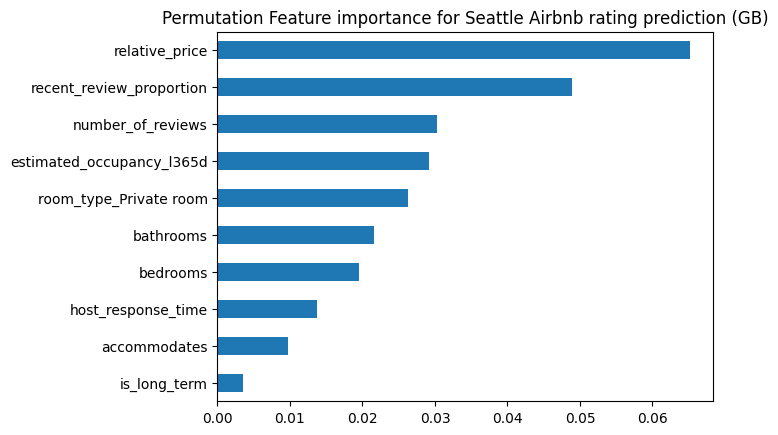

In [40]:
# Visualization

perm_imp.sort_values().tail(10).plot(kind="barh")
plt.title("Permutation Feature importance for Seattle Airbnb rating prediction (GB)")
plt.show()

- **Based on the graph above, `relative_price` appears to be the most important feature in predicting Seattle Airbnb rating scores, followed by `recent_review_proportion` and `number_of_reviews`, which are closely related to user feedback.**
- **This suggests that listings with higher relative prices may be associated with higher ratings. In addition, features such as the number of `bathrooms` and `bedrooms` also show some influence on ratings, though their impact is smaller compared to price and review-related features.**

### RQ2: Does the importance of these features differ across cities compared to Seattle?

Based on the accuracy result above, we use `Gradient Boosting` as our model to do the features importance across cities compared to overall Seattle.

In [41]:
def run_gb_by_area(df, area_name, target_col="review_scores_rating", min_rows=100,
                   test_size=0.2, random_state=42, plot_top_n=10):
    df = df.dropna(subset=[target_col]).copy()

    if len(df) < min_rows:
        raise ValueError(f"{area_name}: Not enough rows ({len(df)})")

    # threshold
    thres = df[target_col].quantile(0.5)

    # X, y
    X = df.drop(columns=[target_col]).copy()
    y = (df[target_col] >= thres).astype(int)

    # one-hot encoding
    X = pd.get_dummies(X, drop_first=True)

    if y.nunique() < 2:
        raise ValueError(f"{area_name}: Only one class in target")

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    gb = GradientBoostingClassifier(learning_rate=0.05,
                                    n_estimators=500,
                                    max_depth=4,
                                    subsample=1.0,
                                    random_state=42)
    gb.fit(X_train, y_train)
    
    # prediction
    y_pred = gb.predict(X_test)

    # permutation feature importance
    result = permutation_importance(gb, X_test, y_test, n_repeats=5, random_state=42)
    perm_imp = pd.Series(result.importances_mean, index=X_test.columns)
    top_features = perm_imp.sort_values(ascending=False).head(plot_top_n)

    # results
    result = {
        "area": area_name,
        "threshold": thres,
        "accuracy": accuracy_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "feature_importance": perm_imp,
        "top_features": top_features,
        "model": gb
    }

    return result

In [42]:
df["neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
Other neighborhoods    1031
Downtown                542
Central Area            443
Capitol Hill            407
Queen Anne              396
West Seattle            388
Ballard                 293
Rainier Valley          263
University District     213
Beacon Hill             206
Northgate               164
Delridge                163
Cascade                 124
Lake City                86
Magnolia                 83
Seward Park              47
Interbay                 14
Name: count, dtype: int64

**To decide the areas we want to research, we pick neighbourhoods with 100+ rows and more than 60%+ accuracy.**

In [43]:
area_list = df["neighbourhood_group_cleansed"].unique()

all_results = {}

for area in area_list:
    try:
        tmp = df[df['neighbourhood_group_cleansed'] == area]
        result = run_gb_by_area(tmp, area)
        all_results[area] = result

        if result["accuracy"] >= 0.60:
            print(f"\n=== {area} ===")
            print("Threshold:", result["threshold"])
            print("Accuracy:", result["accuracy"])
            print("Confusion Matrix:\n", result["confusion_matrix"])

    except Exception as e:
        print(f"\n=== {area} ===")
        print("Error:", e)


=== Other neighborhoods ===
Threshold: 4.92
Accuracy: 0.6908212560386473
Confusion Matrix:
 [[69 33]
 [31 74]]

=== Magnolia ===
Error: Magnolia: Not enough rows (83)

=== Queen Anne ===
Threshold: 4.91
Accuracy: 0.6
Confusion Matrix:
 [[19 17]
 [15 29]]

=== Downtown ===
Threshold: 4.85
Accuracy: 0.6513761467889908
Confusion Matrix:
 [[35 18]
 [20 36]]

=== Central Area ===
Threshold: 4.91
Accuracy: 0.6067415730337079
Confusion Matrix:
 [[25 19]
 [16 29]]

=== University District ===
Threshold: 4.67
Accuracy: 0.7906976744186046
Confusion Matrix:
 [[18  3]
 [ 6 16]]

=== Delridge ===
Threshold: 4.91
Accuracy: 0.6060606060606061
Confusion Matrix:
 [[10  6]
 [ 7 10]]

=== Northgate ===
Threshold: 4.84
Accuracy: 0.6060606060606061
Confusion Matrix:
 [[ 8  8]
 [ 5 12]]

=== Seward Park ===
Error: Seward Park: Not enough rows (47)

=== Lake City ===
Error: Lake City: Not enough rows (86)

=== Interbay ===
Error: Interbay: Not enough rows (14)


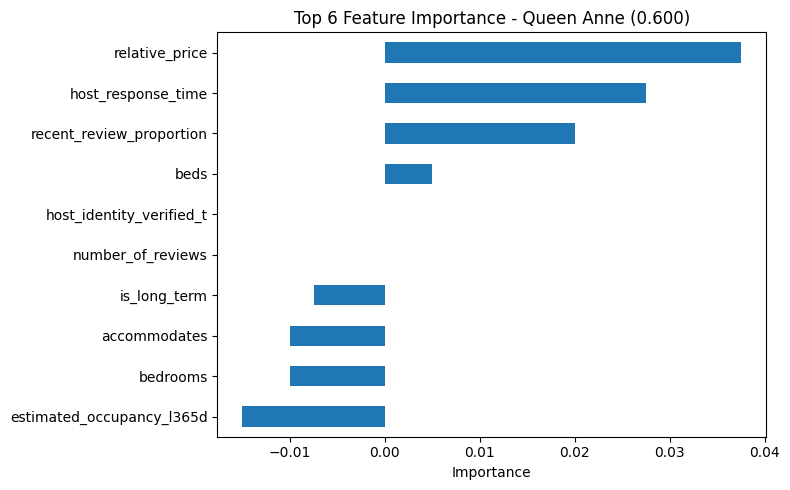

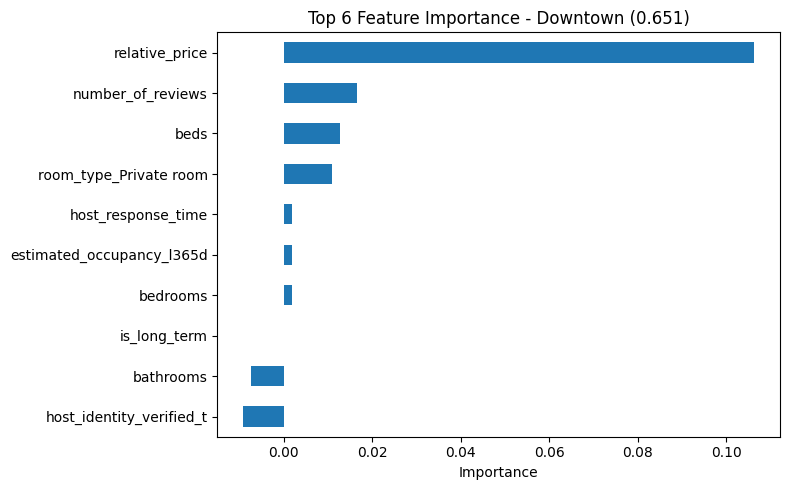

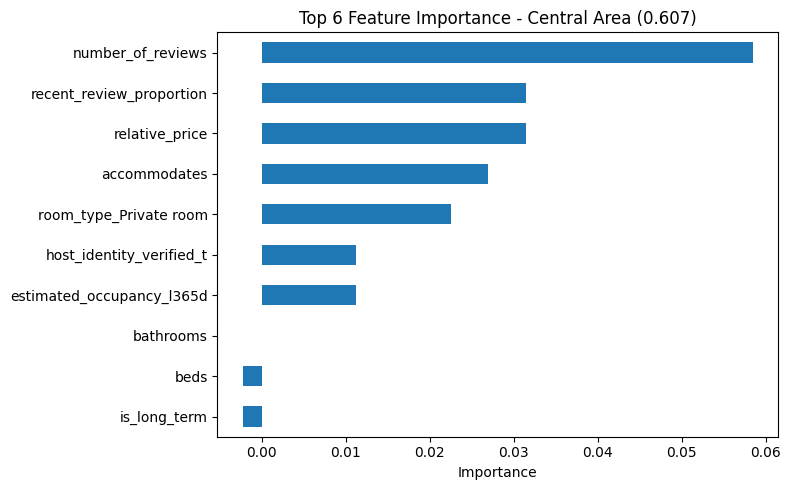

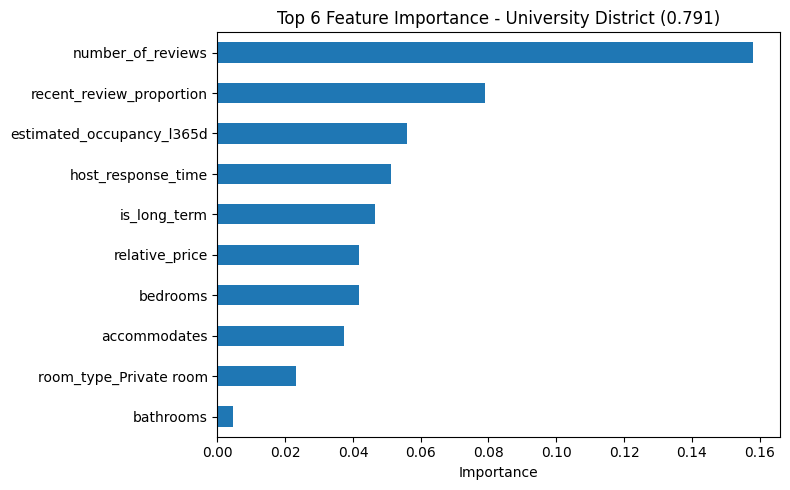

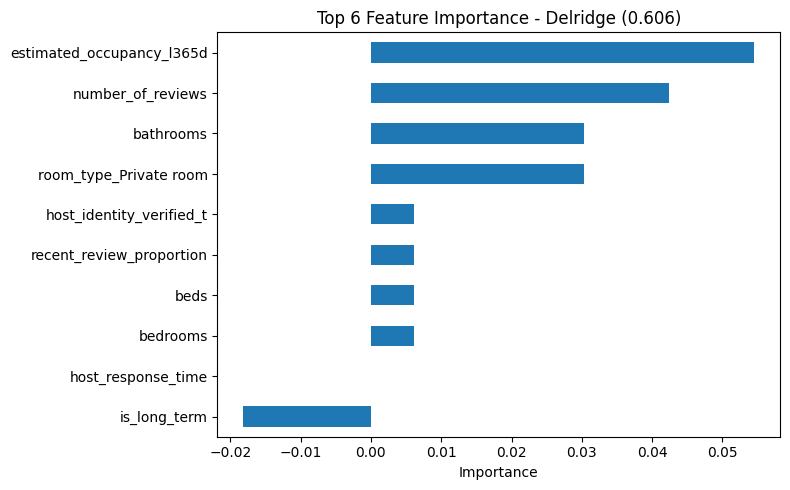

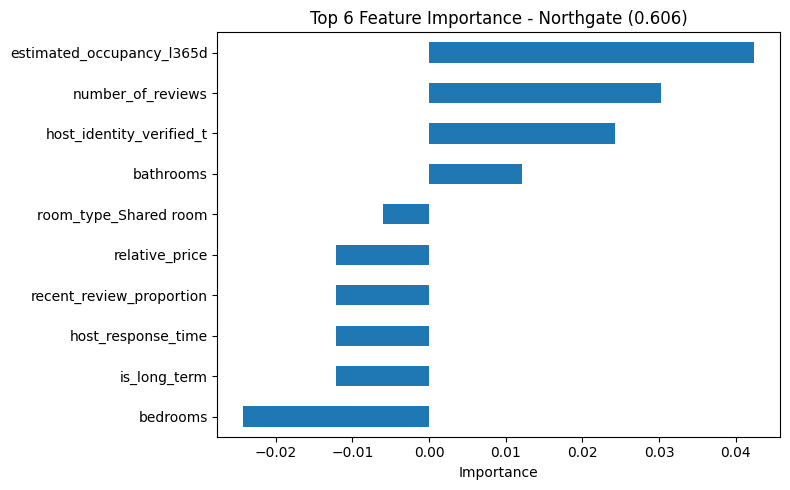

In [44]:
for area_name, result in all_results.items():

    if area_name == "Other neighborhoods":
        continue
    if result["accuracy"] < 0.60:
        continue

    plt.figure(figsize=(8, 5))
    result["top_features"].sort_values(ascending=True).plot(kind="barh")
    
    plt.title(f"Top 6 Feature Importance - {area_name} ({result['accuracy']:.3f})")
    plt.xlabel("Importance")
    
    plt.tight_layout()
    plt.show()

### Neighborhood Segmentation

Note: These are associations, not causal effects. High importance does not imply a positive direction. For example, if relative price is important, higher-priced listings may also receive higher ratings due to better quality.

If relative price ranks within top 4, it is considered important. If not, the area may be less price-sensitive or have low price variance.

#### Group 1: Review-Sensitive (Central Area, U-District)

- Key features:
    - number_of_reviews
    - recent_review_proportion
    - (+ Central: relative_price)
    - (+ U-District: host_response_time)
- Interpretation: <br>
  Ratings are driven by social proof and recency. Listings with more and recent reviews tend to perform better.
- Difference:
    - Central → more diverse demand
    - U-District → faster turnover, more responsive interaction needed

#### Group 2: Occupancy-Sensitive (Northgate, Delridge)

- Key features:
    - estimated_occupancy_l365d
    - number_of_reviews
    - bathrooms / beds
- Interpretation: <br>
  Ratings are associated with utilization and functional quality. Well-performing, frequently booked listings tend to have higher ratings.
- Difference:
    - Northgate → trust/stability (host verification)
    - Delridge → practicality (room type, affordability)
      
#### Group 3: Price + Review-Sensitive (Downtown)
- Key features:
    - relative_price
    - number_of_reviews
    - beds
- Interpretation: <br>
  A market-driven area where both price differentiation and social proof are critical. Price importance may reflect quality differences, not just affordability.

#### Group 4: Price + Experience-Sensitive (Queen Anne)
- Key features:
    - relative_price
    - host_response_time
    - recent_review_proportion
- Interpretation: <br>
  Ratings depend on both price and host experience. Responsiveness and active listings play a key role.

#### Key Insight
**The drivers of ratings vary by neighborhood: some rely on reviews, others on occupancy, price, or host interaction, indicating that “quality” is context-dependent.**

### 5. Conduct a hyperparameter sensitivity analysis by systematically varying key model parameters and measuring their impact on model performance.

We conducted hyperparameter sensitivity analysis across three models:
- `KNN`: <br>
  n_neighbors Varied k from 3 to 19. Accuracy steadily increased up to k=13 (0.6308) and declined after, suggesting k=13 as optimal. Small k values caused overfitting, while large k values oversmoothed decision boundaries.
- `Random Forest`: <br>
  n_estimators Varied from 50 to 500. Contrary to typical expectations, performance peaked at n_estimators=50 (0.6390) and gradually decreased with more trees, suggesting the additional trees introduced noise rather than improving generalization.
- `Gradient Boosting`: <br>
  learning_rate Varied from 0.01 to 0.5. Performance peaked at learning_rate=0.2 (0.6554). Very low rates (0.01) underfit due to insufficient weight updates, while too high a rate (0.5) caused overshooting and degraded performance.

### 6. Report the evaluation of your model. 

We evaluated all four models using Accuracy on a binary classification task predicting whether an Airbnb listing receives a high or low review score.

- For `KNN`, we varied k from 3 to 19. Accuracy steadily improved from 0.5867 at k=3 to a peak of 0.6308 at k=13, then declined. This indicates that too small a k leads to overfitting, while too large a k oversmooths the decision boundary.
- For `Random Forest`, we varied n_estimators from 50 to 500. Performance peaked at n_estimators=50 with an accuracy of 0.6390 and gradually decreased as more trees were added. This suggests that additional trees introduced noise rather than improving generalization on this dataset.
- For `GBM`, we varied learning_rate from 0.01 to 0.5. Accuracy increased from 0.6369 at 0.01 to a peak of 0.6554 at learning_rate=0.2, then sharply dropped to 0.6246 at 0.5, indicating that too high a learning rate causes the model to overshoot optimal weights.

Overall, `GBM` with learning_rate=0.2 achieved the best accuracy of 65.54%, followed by Logistic Regression at 65.13%, Random Forest at 63.90%, and KNN at 63.08%. All models performed within a narrow range, suggesting that hyperparameter tuning provided modest but consistent improvements, and that the feature set itself is the primary limiting factor in predictive performance.

### 7. What challenges did you run into? 

One challenge we encountered early in the project was **defining a clear and feasible research question**. At first, we were interested in exploring Airbnb price differences between cities, states, or even countries. However, we quickly realized that the dataset lacked important variables needed for this type of analysis. For example, the dataset does not include booking date information, which makes it difficult to analyze seasonal pricing patterns. 

Additionally, **comparing prices across different geographic areas introduces many complex factors** such as local demand, tourism, cost of living, and regional regulations. These differences made cross-location price analysis too complicated to conduct accurately with the available data.

Because of these limitations, we adjusted our research focus. Instead of predicting price, we decided to **predict Airbnb rating scores**, which are one of the most important factors users consider when choosing a place to stay. Initially, we used regression models to predict the exact rating score, since ratings are continuous numerical values. However, the model performance was not strong, partly because Airbnb ratings tend to have very little variation and are heavily skewed toward high values. This makes it difficult for regression models to capture meaningful differences.

To address this issue, we reframed the task as a **classification** problem, predicting whether a listing has a high rating or low rating based on the median rating score as the threshold. This transformation simplified the prediction problem and improved model performance. We also carefully selected features and created some calculated variables while trying to avoid multicollinearity. 

Finally, we compared several models and selected **Gradient Boosting Classifier** as the best-performing model to analyze feature importance and compare results across different neighborhoods in Seattle.


### 8. Explain how your machine learning solution answers the research question you defined. 


Our research question focuses on **predicting Airbnb rating outcomes** and understanding **which features influence ratings across different neighborhoods in Seattle**. <br>
The machine learning approach answers this question by using **listing characteristics**—such as price, room type, host status, number of reviews, and accommodation capacity—to predict whether a listing will receive a high or low rating. <br>
After comparing multiple models, we found that the Gradient Boosting Classifier achieved the best performance. This model is especially effective because it builds trees sequentially and improves prediction errors step by step, allowing it to capture complex and nonlinear relationships in the data. It also provides feature importance scores, which help us identify which factors have the strongest influence on ratings in different neighborhoods.

One advantage of this approach is that it can **uncover patterns that are not easily visible** through simple statistical analysis. <br>
For example, it can show whether host-related factors (such as being a superhost) or listing characteristics (such as price or number of bedrooms) play a more important role in determining high ratings. When applied to unseen data, the model can help hosts understand which aspects of their listings may improve guest satisfaction and assist users in identifying listings that are more likely to receive high ratings.

However, there are also risks when applying this model to new data. <br>
If the model **overfits** the training data or if future Airbnb listings differ significantly from the current dataset, its predictions may become less accurate. <br>
Additionally, since Airbnb ratings tend to be **highly skewed toward higher values**, the model may struggle to distinguish subtle differences between listings. <br>
If the model makes incorrect predictions, it could mislead hosts into focusing on less important features or cause users to form inaccurate expectations about listing quality. On the other hand, when the model performs well, it can provide meaningful insights that help hosts improve their services and support users in making better booking decisions.

From a societal perspective, this model has both positive and negative impacts. <br>
- On the positive side, it **increases transparency** by highlighting the key factors that contribute to higher ratings, which may encourage hosts to improve quality and consistency. It can also **make the booking process more efficient for users**. <br>
- However, there are potential downsides. The model may unintentionally **reinforce existing inequalities**, such as favoring certain neighborhoods, property types, or hosts with more resources. Additionally, over-reliance on model predictions could **reduce the importance of personal experience and qualitative factors in hospitality**.


### 9. Name one research question you might ask next for future work 

**How does pricing strategy affect the probability of receiving a high Airbnb rating?** <br>
This question is important because price is one of the most visible factors in the Airbnb marketplace. <br>
While our current model includes price as a feature, it does not fully analyze how different price levels influence guest satisfaction or perceived value. Investigating this relationship could help hosts balance profitability and customer satisfaction, and it could also provide insights into how guests evaluate value when booking accommodations. <br>
Understanding this relationship would further improve both pricing strategies and recommendation systems for Airbnb listings.

### Model Card